# IMPORT LIBRARY

In [1]:
import time
import matplotlib.pyplot as plt
from tabulate import tabulate
import statistics

# PERHITUNGAN WAKTU ANTARA ALGORTIMA ITERATIF DAN REKRUSIF

In [2]:
# Algoritma Iteratif
def total_tabungan_iteratif(n, tabungan_awal):
    total = 0
    for i in range(1, n + 1):
        total += i * tabungan_awal
    return total

# Algoritma Rekursif
def total_tabungan_rekursif(n, tabungan_awal):
    if n == 0:
        return 0
    return n * tabungan_awal + total_tabungan_rekursif(n - 1, tabungan_awal)


In [7]:
tabungan_awal = int(input("Masukkan tabungan awal per bulan: "))
bulan_input = int(input("Masukkan jumlah bulan yang ingin dihitung: "))

start = time.time()
hasil_iteratif = total_tabungan_iteratif(bulan_input, tabungan_awal)
waktu_user_iteratif = time.time() - start

start = time.time()
hasil_rekursif = total_tabungan_rekursif(bulan_input, tabungan_awal)
waktu_user_rekursif = time.time() - start

print(f"Total Tabungan (Iteratif): Rp{hasil_iteratif}")
print(f"Waktu Eksekusi Iteratif: {waktu_user_iteratif:.12e} detik")

print(f"Total Tabungan (Rekursif): Rp{hasil_rekursif}")
print(f"Waktu Eksekusi Rekursif: {waktu_user_rekursif:.12e} detik")

Masukkan tabungan awal per bulan: 10000
Masukkan jumlah bulan yang ingin dihitung: 10
Total Tabungan (Iteratif): Rp550000
Waktu Eksekusi Iteratif: 1.430511474609e-04 detik
Total Tabungan (Rekursif): Rp550000
Waktu Eksekusi Rekursif: 6.794929504395e-05 detik


In [4]:
#Pengujian Efisiensi Algortima

def ukur_waktu(func, *args, ulang=10):
    hasil = []
    for _ in range(ulang):
        start = time.time()
        func(*args)
        hasil.append(time.time() - start)
    return statistics.mean(hasil)

n_values = [10, 100, 200, 300, 400, 500, 700, 900]
tabungan_awal = 10000

waktu_iteratif = []
waktu_rekursif = []

for n in n_values:
    waktu_iteratif.append(ukur_waktu(total_tabungan_iteratif, n, tabungan_awal))
    waktu_rekursif.append(ukur_waktu(total_tabungan_rekursif, n, tabungan_awal))

tabel_data = []

for i in range(len(n_values)):
    tabel_data.append([
        n_values[i],
        f"{waktu_rekursif[i]:.12e}",
        f"{waktu_iteratif[i]:.12e}"
    ])

header = ["n", "Recursive Time (s)", "Iterative Time (s)"]

print(tabulate(tabel_data, headers=header, tablefmt="grid"))


+-----+----------------------+----------------------+
|   n |   Recursive Time (s) |   Iterative Time (s) |
+=====+======================+======================+
|  10 |          1.40667e-06 |          1.19209e-06 |
+-----+----------------------+----------------------+
| 100 |          9.94205e-06 |          5.93662e-06 |
+-----+----------------------+----------------------+
| 200 |          3.4523e-05  |          3.53336e-05 |
+-----+----------------------+----------------------+
| 300 |          5.80311e-05 |          1.76668e-05 |
+-----+----------------------+----------------------+
| 400 |          7.76529e-05 |          2.46048e-05 |
+-----+----------------------+----------------------+
| 500 |          9.97543e-05 |          3.52383e-05 |
+-----+----------------------+----------------------+
| 700 |          0.00014174  |          5.3668e-05  |
+-----+----------------------+----------------------+
| 900 |          0.000195479 |          7.10011e-05 |
+-----+---------------------

# GRAFIK PERBANDINGAN WAKTU EKSEKUSI ALGORTIMA TABUNGAN

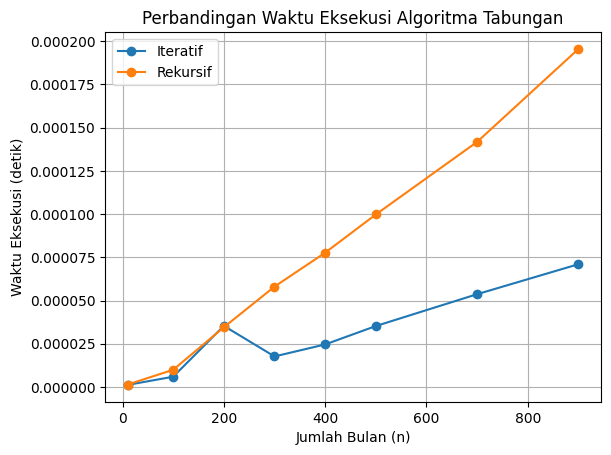

In [5]:
plt.plot(n_values, waktu_iteratif, marker='o', label='Iteratif')
plt.plot(n_values, waktu_rekursif, marker='o', label='Rekursif')
plt.xlabel('Jumlah Bulan (n)')
plt.ylabel('Waktu Eksekusi (detik)')
plt.title('Perbandingan Waktu Eksekusi Algoritma Tabungan')
plt.legend()
plt.grid()
plt.show()